## 1. Data Collection

### 1.1. What is the subject of your data?
* **Topic:** Socioeconomic data.  
* **Context:** The dataset represents the demographic structure of the U.S. population in 1994 and reflects the relationship between demographic characteristics (age, education, marital status, etc.) and individual income levels.  
* **Phenomenon:** Income inequality and the factors influencing the likelihood of earning more than $50K per year.

### 1.2. What is the source of your data?
* **Platform:** Kaggle
* **URL:** https://www.kaggle.com/datasets/uciml/adult-census-income
* **Authors:** Ronny Kohavi and Barry Becker
* **Date:** 01/05/1996 (Extracted from the 1994 U.S. Census Bureau database)

### 1.3. Is this data licensed for your use?
* **License:** CC BY 4.0 (Creative Commons Attribution 4.0 International)  
* **Permission:** Allowed for educational and research use.

### 1.4. How was this data collected?
* **Method:** Extracted from a national census database.  
* **Sampling Criteria:**  
  * Age > 16  
  * Adjusted gross income > 100  
  * Final weight > 1  
  * Hours worked per week > 0  
* **Limitations:**  
  * Data is from 1994, so it does not reflect current inflation or economic conditions.  
  * Noticeable gender imbalance (more males than females).

### 1.5. Why did you choose this dataset?
* **Historical Context:** It serves as a snapshot of the 1994 US economy, where the $50K threshold was a high-income benchmark (significantly above the median of $32K), reflecting a distinct era of American prosperity. 
* **Global Perspective:** 1994 is also a pivotal year for Vietnam, marking the lifting of the US trade embargo. Analyzing US economic data from this specific year provides a fascinating contrast between a developed economy and Vietnam's emerging market during the same historical moment.
* **Interests:** To explore how education level and marital status influence financial prosperity.  
* **Insights:** The dataset is suitable for practicing categorical variable processing, handling imbalanced data, and applying binary classification models.

## 2. Data Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

### 2.1 Data Overview

#### Basic Information
At this step, we are performing a basic overview of the dataset to understand its structure and attributes:

1. **Loading the dataset**  
   - The CSV file is read into a Pandas DataFrame to allow further analysis.

2. **Previewing the data**  
   - A small portion of the dataset is displayed to inspect the types of values in each column and to get an initial sense of the data.

3. **Examining dataset information**  
   - Using `.info()`, we check the number of rows and columns, the data types of each attribute, and the counts of non-missing values.  
   - This helps identify which columns are numeric, categorical, or require cleaning.

**Purpose:**  
- To get a quick understanding of the dataset’s size, structure, and variable types before proceeding to more detailed analysis such as column inventory, data type corrections, and numerical exploration.

In [2]:
# Read .csv file
df = pd.read_csv("../data/adult.csv")

# Display a part of data
display(df)

# Information about dataset's attributes
df.info()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#### 2.1.1 Data Integrity
At this stage, we are assessing the **quality and reliability** of the dataset by checking for duplicate and entirely empty rows.

**Checking for duplicates**
- We count rows that appear more than once.  
- **Why:** Duplicate rows can bias analysis and machine learning models by over-representing certain individuals, and can lead to data leakage if the same row is in both training and test sets.  
- Any duplicates are flagged for removal to ensure a **clean and unbiased dataset**.

**Checking for empty rows**
- We check if any row has all missing values.  
- **Why:** Rows with no valid data provide no information for analysis and should be removed.  
- Ensures that subsequent analysis operates only on meaningful data.

**Purpose of this step**
- To ensure the dataset is **complete and consistent**.  
- To identify any data issues early so that further exploration, column inventory, and statistical analysis can be done reliably.

In [3]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print(f"The number of duplicated rows: {duplicate_count} rows.")

# Show some duplicate rows
if duplicate_count > 0:
    print("Sample of duplicated rows:")
    display(df[df.duplicated()].head(5))

# Check entirely empty rows
# axis=1 check each row
empty_rows_count = df.isnull().all(axis=1).sum()
if empty_rows_count > 0:
    print(f"There are {empty_rows_count} entirely empty rows.")
else:
    print(f"All rows have at least some data.")


The number of duplicated rows: 24 rows.
Sample of duplicated rows:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
8453,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
8645,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
12202,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
14346,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
15603,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K


All rows have at least some data.


#### 2.1.2 Column Inventory

At this step, we are reviewing all columns to understand their **role, importance, and potential issues**.  

- **Understand meaning:** Identify what each column represents (e.g., age, education, work hours).  
- **Assess relevance:** Determine which columns are meaningful for income analysis and which are secondary or redundant.  
- **Flag for preprocessing:** Decide which columns need cleaning, type conversion, or removal due to low variance or duplicates.  

**Purpose:** Ensure subsequent analysis uses **clean, relevant, and interpretable variables**.

**Column Description**

| Variable Name | Description / Values |
| :--- | :--- |
| **age** | The age of the individual. |
| **workclass** | Employment sector (e.g., *Private, Self-emp-not-inc, Federal-gov, Local-gov*...). |
| **fnlwgt** | Final Weight. A statistical weight assigned by the Census Bureau representing the number of people this row stands for. |
| **education** | Highest education level (e.g., *Bachelors, HS-grad, Doctorate*...). |
| **education.num** | Numeric representation of education level (e.g., 13 for Bachelors). |
| **marital.status** | Marital status (e.g., *Married-civ-spouse, Divorced, Never-married*...). |
| **occupation** | Job role (e.g., *Tech-support, Craft-repair, Exec-managerial*...). |
| **relationship** | Role in the family (e.g., *Wife, Own-child, Husband, Not-in-family*...). |
| **race** | Race description (*White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black*). |
| **sex** | Biological sex (*Female, Male*). |
| **capital.gain** | Income from investment sources. |
| **capital.loss** | Losses from investment sources. |
| **hours.per.week** | Number of hours worked per week. |
| **native.country** | Country of origin (e.g., *United-States, Mexico, Vietnam, Germany*...). |
| **income** | Target variable indicating income class (*>50K, <=50K*). |



**Columns with High Potential**

- **age** – Numeric, highly relevant. Age strongly influences experience, career stage, and income potential.  
- **education** – Categorical, highly relevant. Education level is a key factor in earning potential and skill qualification.  
- **marital.status** – Categorical, highly relevant. Marital status may reflect life stability and household income patterns.  
- **race** – Categorical, highly relevant. Useful for analyzing social and income disparities.  
- **sex** – Categorical, highly relevant. Gender is often correlated with income differences.  
- **hours.per.week** – Numeric, highly relevant. Work hours directly affect income.  
- **native.country** – Categorical, highly relevant. Country of origin can impact socioeconomic status and earning potential.  
- **income** – Target variable, highly relevant. Directly indicates the outcome of interest.


**Columns with Moderate or Optional Potential**

- **workclass** – Categorical, moderately relevant. Indicates employment type which may correlate with income.  
- **occupation** – Categorical, moderately relevant. Job role affects earnings, but may overlap with workclass.  
- **fnlwgt** – Numeric, optional. Represents census weight; only needed for weighted population analysis.  
- **relationship** – Categorical, optional. Family role may overlap with marital status; useful in household-level analysis.

**Columns Recommended to Drop**

- **capital.gain** – Numeric. Mostly zeros; provides no variance or predictive power in this dataset.  
- **capital.loss** – Numeric. Mostly zeros; similarly, no useful information for analysis.  
- **education.num** – Numeric. Duplicate of `education`; keeping both may cause multicollinearity without adding value.


#### 2.1.3 Data Type
At this step, we examine the **current data types** of all columns to ensure they are appropriate for analysis.

- **Identify inappropriate types:** Some categorical columns may be stored as objects, and the target variable (`income`) is currently an object.  
- **Plan type conversion:** Convert categorical columns to `category` for memory efficiency and better handling in analysis. Convert numeric columns stored as objects to `int` or `float` after handling missing values.  

**Purpose:**  
- Ensure each column has the correct type for accurate computations, statistical analysis, and later modeling.  
- Prevent errors and improve efficiency in data processing.


In [4]:
# Check the current data type of attributes
print("Current Data Types:")
print(df.dtypes)

Current Data Types:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


**Columns with Inappropriate Data Types**

- **income** – currently `object`. Needs conversion to `category` for proper analysis.  
- **Categorical columns stored as object** (workclass, education, marital.status, occupation, relationship, race, sex, native.country) → optional conversion to `category` for memory efficiency and better handling in Pandas/statistics.  
- Numeric columns are appropriate.


**Columns Needing Type Conversion**

- **income** → `category`
- **workclass, education, marital.status, occupation, relationship, race, sex, native.country** → `category` 
- Numeric columns stored as object → convert to int/float after handling missing values (if any).

### 2.2 Numerical Columns Analysis

At this step, we explore all numeric columns to understand their **distribution, central tendency, range, and potential outliers**.

- **Summary statistics:**  
  Compute count, mean, median, standard deviation, min, max, quartiles, and IQR for each numeric column.  
  This helps capture the overall behavior of numeric features like `age` and `hours.per.week`.

- **Outlier detection:**  
  Identify extreme values using the IQR method and visualize with boxplots.  

- **Distribution visualization:**  
  Plot histograms with KDE and boxplots to examine distribution shapes and highlight variability.

- **Data quality check:**  
  Verify missing values and placeholders (`?`), and flag any impossible values (e.g., negative numbers).

**Purpose:**  
- Gain insights into numeric feature characteristics.  
- Detect and handle potential data issues before further analysis or modeling.

#### 2.2.1 Distribution & Central Tendency

In [5]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Initialize a list to store summary for each column
numeric_summary = []

for col in numeric_cols:
    # Descriptive statistics
    count = df[col].count()
    mean = df[col].mean()
    median = df[col].median()
    std = df[col].std()
    min_val = df[col].min()
    max_val = df[col].max()
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Outlier detection using IQR
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    # Store all info in a dictionary
    numeric_summary.append({
        'Column': col,
        'Count': count,
        'Mean': round(mean,2),
        'Median': round(median,2),
        'Std': round(std,2),
        'Min': min_val,
        'Q1': Q1,
        'Q3': Q3,
        'Max': max_val,
        'IQR': IQR,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outliers': outliers_count
    })

# Convert list of dictionaries to DataFrame
numeric_summary_df = pd.DataFrame(numeric_summary)

# Round numeric columns for better readability
numeric_summary_df = numeric_summary_df.round(2)

# Transpose the numeric summary
numeric_summary_df_T = numeric_summary_df.set_index('Column').T

# Display
numeric_summary_df_T


Column,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
Count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
Mean,38.58,189778.37,10.08,1077.65,87.30,40.44
Median,37.00,178356.00,10.00,0.00,0.00,40.00
Std,13.64,105549.98,2.57,7385.29,402.96,12.35
Min,17.00,12285.00,1.00,0.00,0.00,1.00
Q1,28.00,117827.00,9.00,0.00,0.00,40.00
Q3,48.00,237051.00,12.00,0.00,0.00,45.00
Max,90.00,1484705.00,16.00,99999.00,4356.00,99.00
IQR,20.00,119224.00,3.00,0.00,0.00,5.00
Lower Bound,-2.00,-61009.00,4.50,0.00,0.00,32.50


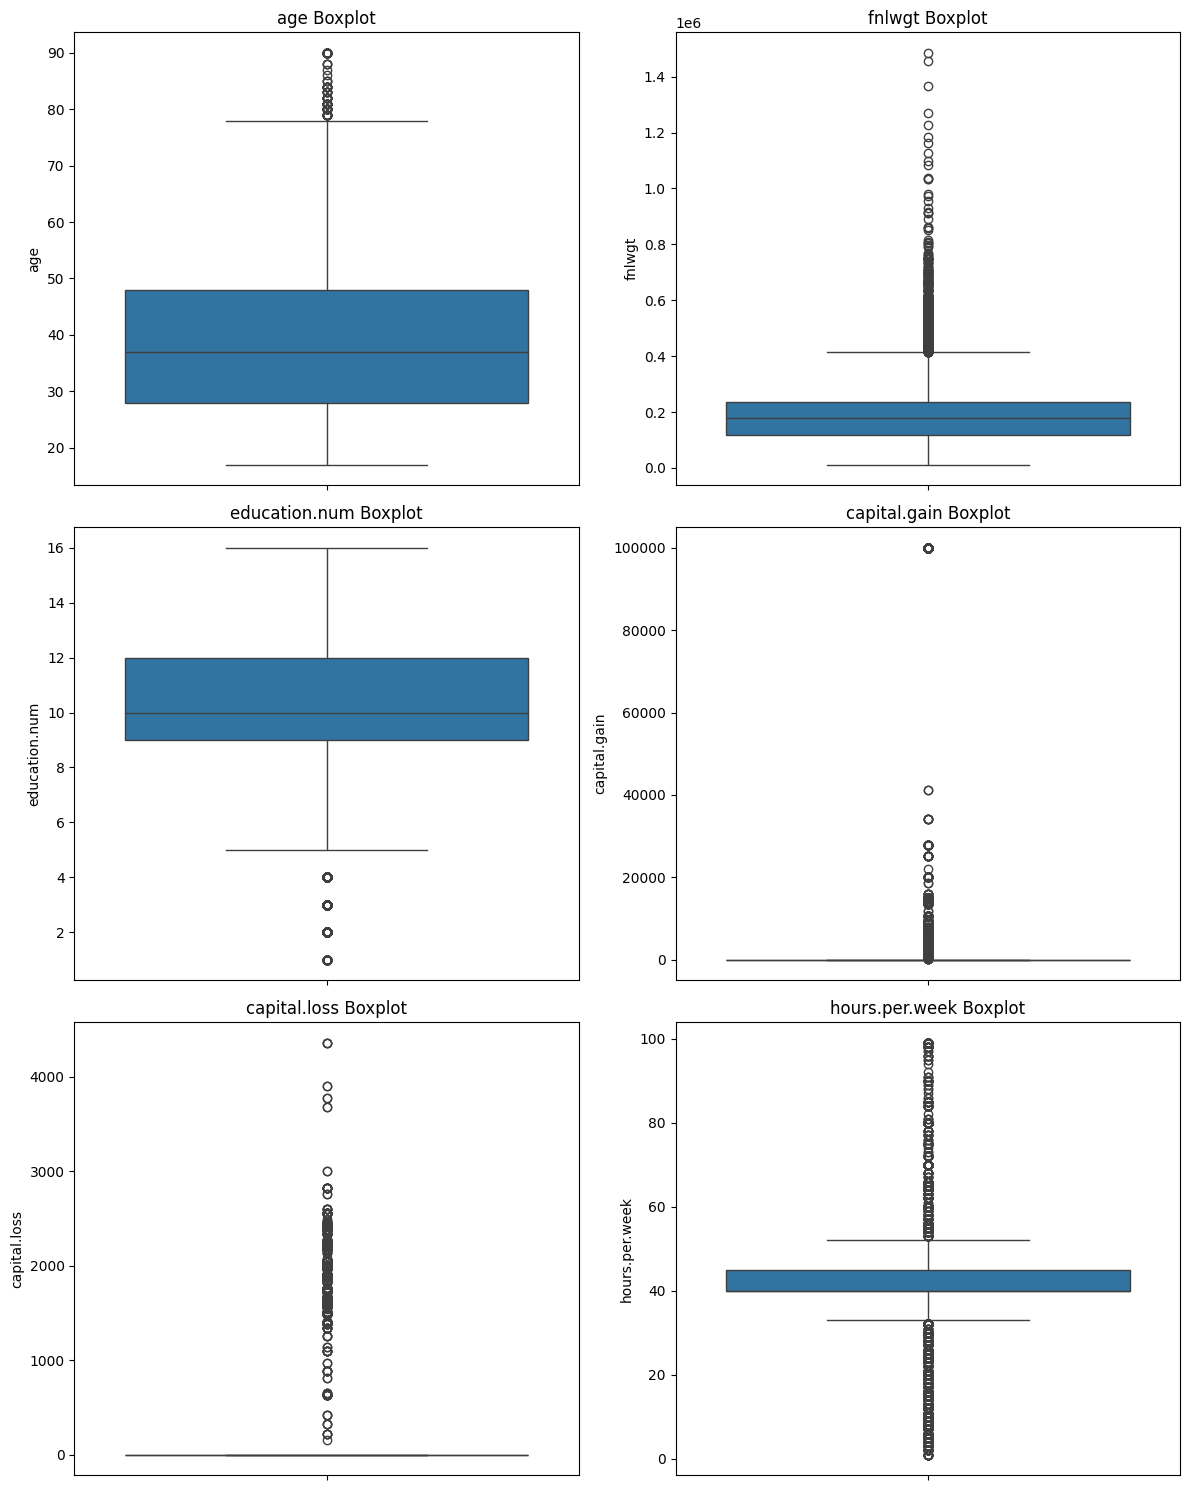

In [6]:
# Number of boxplots per row
cols_per_row = 2
n_rows = math.ceil(len(numeric_cols) / cols_per_row)

# Create figure and axes
fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(12, 5*n_rows))

# If only 1 row, make axes iterable
if n_rows == 1:
    axes = [axes]

# Flatten axes array for looping
axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"{col} Boxplot")

# Remove any extra axes if number of numeric columns is odd
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

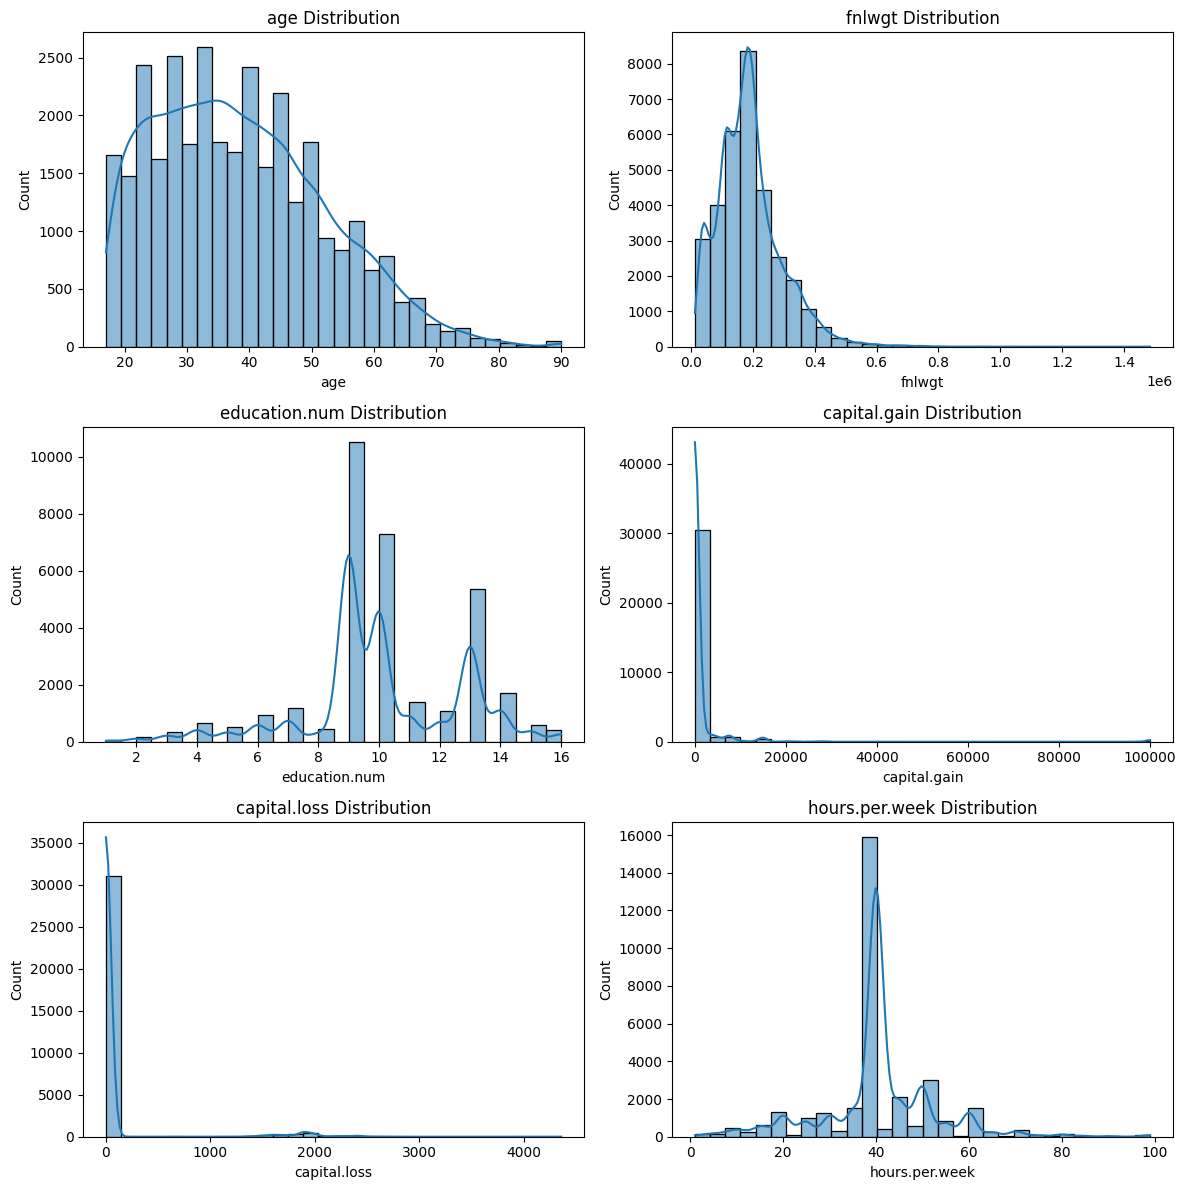

In [7]:
# Create figure and axes
fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(12, 4*n_rows))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot histogram + KDE for each numeric column
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

# Remove any extra axes if number of numeric columns is odd
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


#### 2.2.2 Data Quality

In [8]:
# Initialize list to store data quality info
data_quality = []

for col in numeric_cols:
    # Count placeholders ("?") in the original dataframe
    placeholder_count = (df[col] == '?').sum()
    
    # Count negative values
    negative_count = (df[col] < 0).sum()
    
    # Count positive values
    positive_count = (df[col] > 0).sum()
    
    data_quality.append({
        'Column': col,
        'Placeholders (?)': placeholder_count,
        'Negative Values': negative_count,
        'Positive Values': positive_count
    })

# Convert to DataFrame for display
data_quality_df = pd.DataFrame(data_quality)
data_quality_df


,Column,Placeholders (?),Negative Values,Positive Values
0,age,0,0,32561
1,fnlwgt,0,0,32561
2,education.num,0,0,32561
3,capital.gain,0,0,2712
4,capital.loss,0,0,1519
5,hours.per.week,0,0,32561


**Conclusion:**  
- Most numeric columns are complete and have reasonable ranges.  
- `capital.gain` and `capital.loss` contain mostly zeros, providing little variability.  
- Outliers exist in some columns but appear to be genuine extreme values rather than errors.  

### 2.3 Categorical Columns Analysis

#### 2.3.1 Value Distribution

At this stage, we explore the **distribution of values** in each categorical column to understand how the categories are represented in the dataset.

- **Unique Values:** Count the number of distinct categories per column (excluding placeholders “?”). Columns like `education`, `occupation`, and `native.country` have many categories, while `sex` and `race` have few.  
- **Top Categories:** Identify the top 5 most frequent categories and their percentage of total samples.  
- **Visualization:** Countplots are used to visualize category distributions. For columns with many categories, only the top 10 most frequent values are plotted for clarity. Numbers on bars indicate the actual counts.
- **Distribution Balance:** Assess if the distribution is balanced or imbalanced based on the proportion of the top category:  
  - Balanced ≤ 40%
  - Moderately imbalanced 40–70%
  - Highly imbalanced >70%  

In [9]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Initialize summary list
cat_summary = []

for col in categorical_cols:
    total = df.shape[0]

    # Unique values excluding '?'
    unique_count = df[col][df[col] != "?"].nunique()

    # Top 5 most frequent values (excluding '?')
    top_values = df[df[col] != "?"][col].value_counts().head(5)

    # Convert top values to "value (xx.x%)"
    top_values_formatted = [
        f"{idx} ({round((count/total)*100, 2)}%)"
        for idx, count in top_values.items()
    ]

    while len(top_values_formatted) < 5:
        top_values_formatted.append("")

    cat_summary.append({
        "Column": col,
        "Unique Values": unique_count,
        "Top 1": top_values_formatted[0],
        "Top 2": top_values_formatted[1],
        "Top 3": top_values_formatted[2],
        "Top 4": top_values_formatted[3],
        "Top 5": top_values_formatted[4],
    })

categorical_summary_df = pd.DataFrame(cat_summary)
categorical_summary_df


,Column,Unique Values,Top 1,Top 2,Top 3,Top 4,Top 5
0,workclass,8,Private (69.7%),Self-emp-not-inc (7.8%),Local-gov (6.43%),State-gov (3.99%),Self-emp-inc (3.43%)
1,education,16,HS-grad (32.25%),Some-college (22.39%),Bachelors (16.45%),Masters (5.29%),Assoc-voc (4.24%)
2,marital.status,7,Married-civ-spouse (45.99%),Never-married (32.81%),Divorced (13.65%),Separated (3.15%),Widowed (3.05%)
3,occupation,14,Prof-specialty (12.71%),Craft-repair (12.59%),Exec-managerial (12.49%),Adm-clerical (11.58%),Sales (11.21%)
4,relationship,6,Husband (40.52%),Not-in-family (25.51%),Own-child (15.56%),Unmarried (10.58%),Wife (4.82%)
5,race,5,White (85.43%),Black (9.59%),Asian-Pac-Islander (3.19%),Amer-Indian-Eskimo (0.96%),Other (0.83%)
6,sex,2,Male (66.92%),Female (33.08%),,,
7,native.country,41,United-States (89.59%),Mexico (1.97%),Philippines (0.61%),Germany (0.42%),Canada (0.37%)
8,income,2,<=50K (75.92%),>50K (24.08%),,,


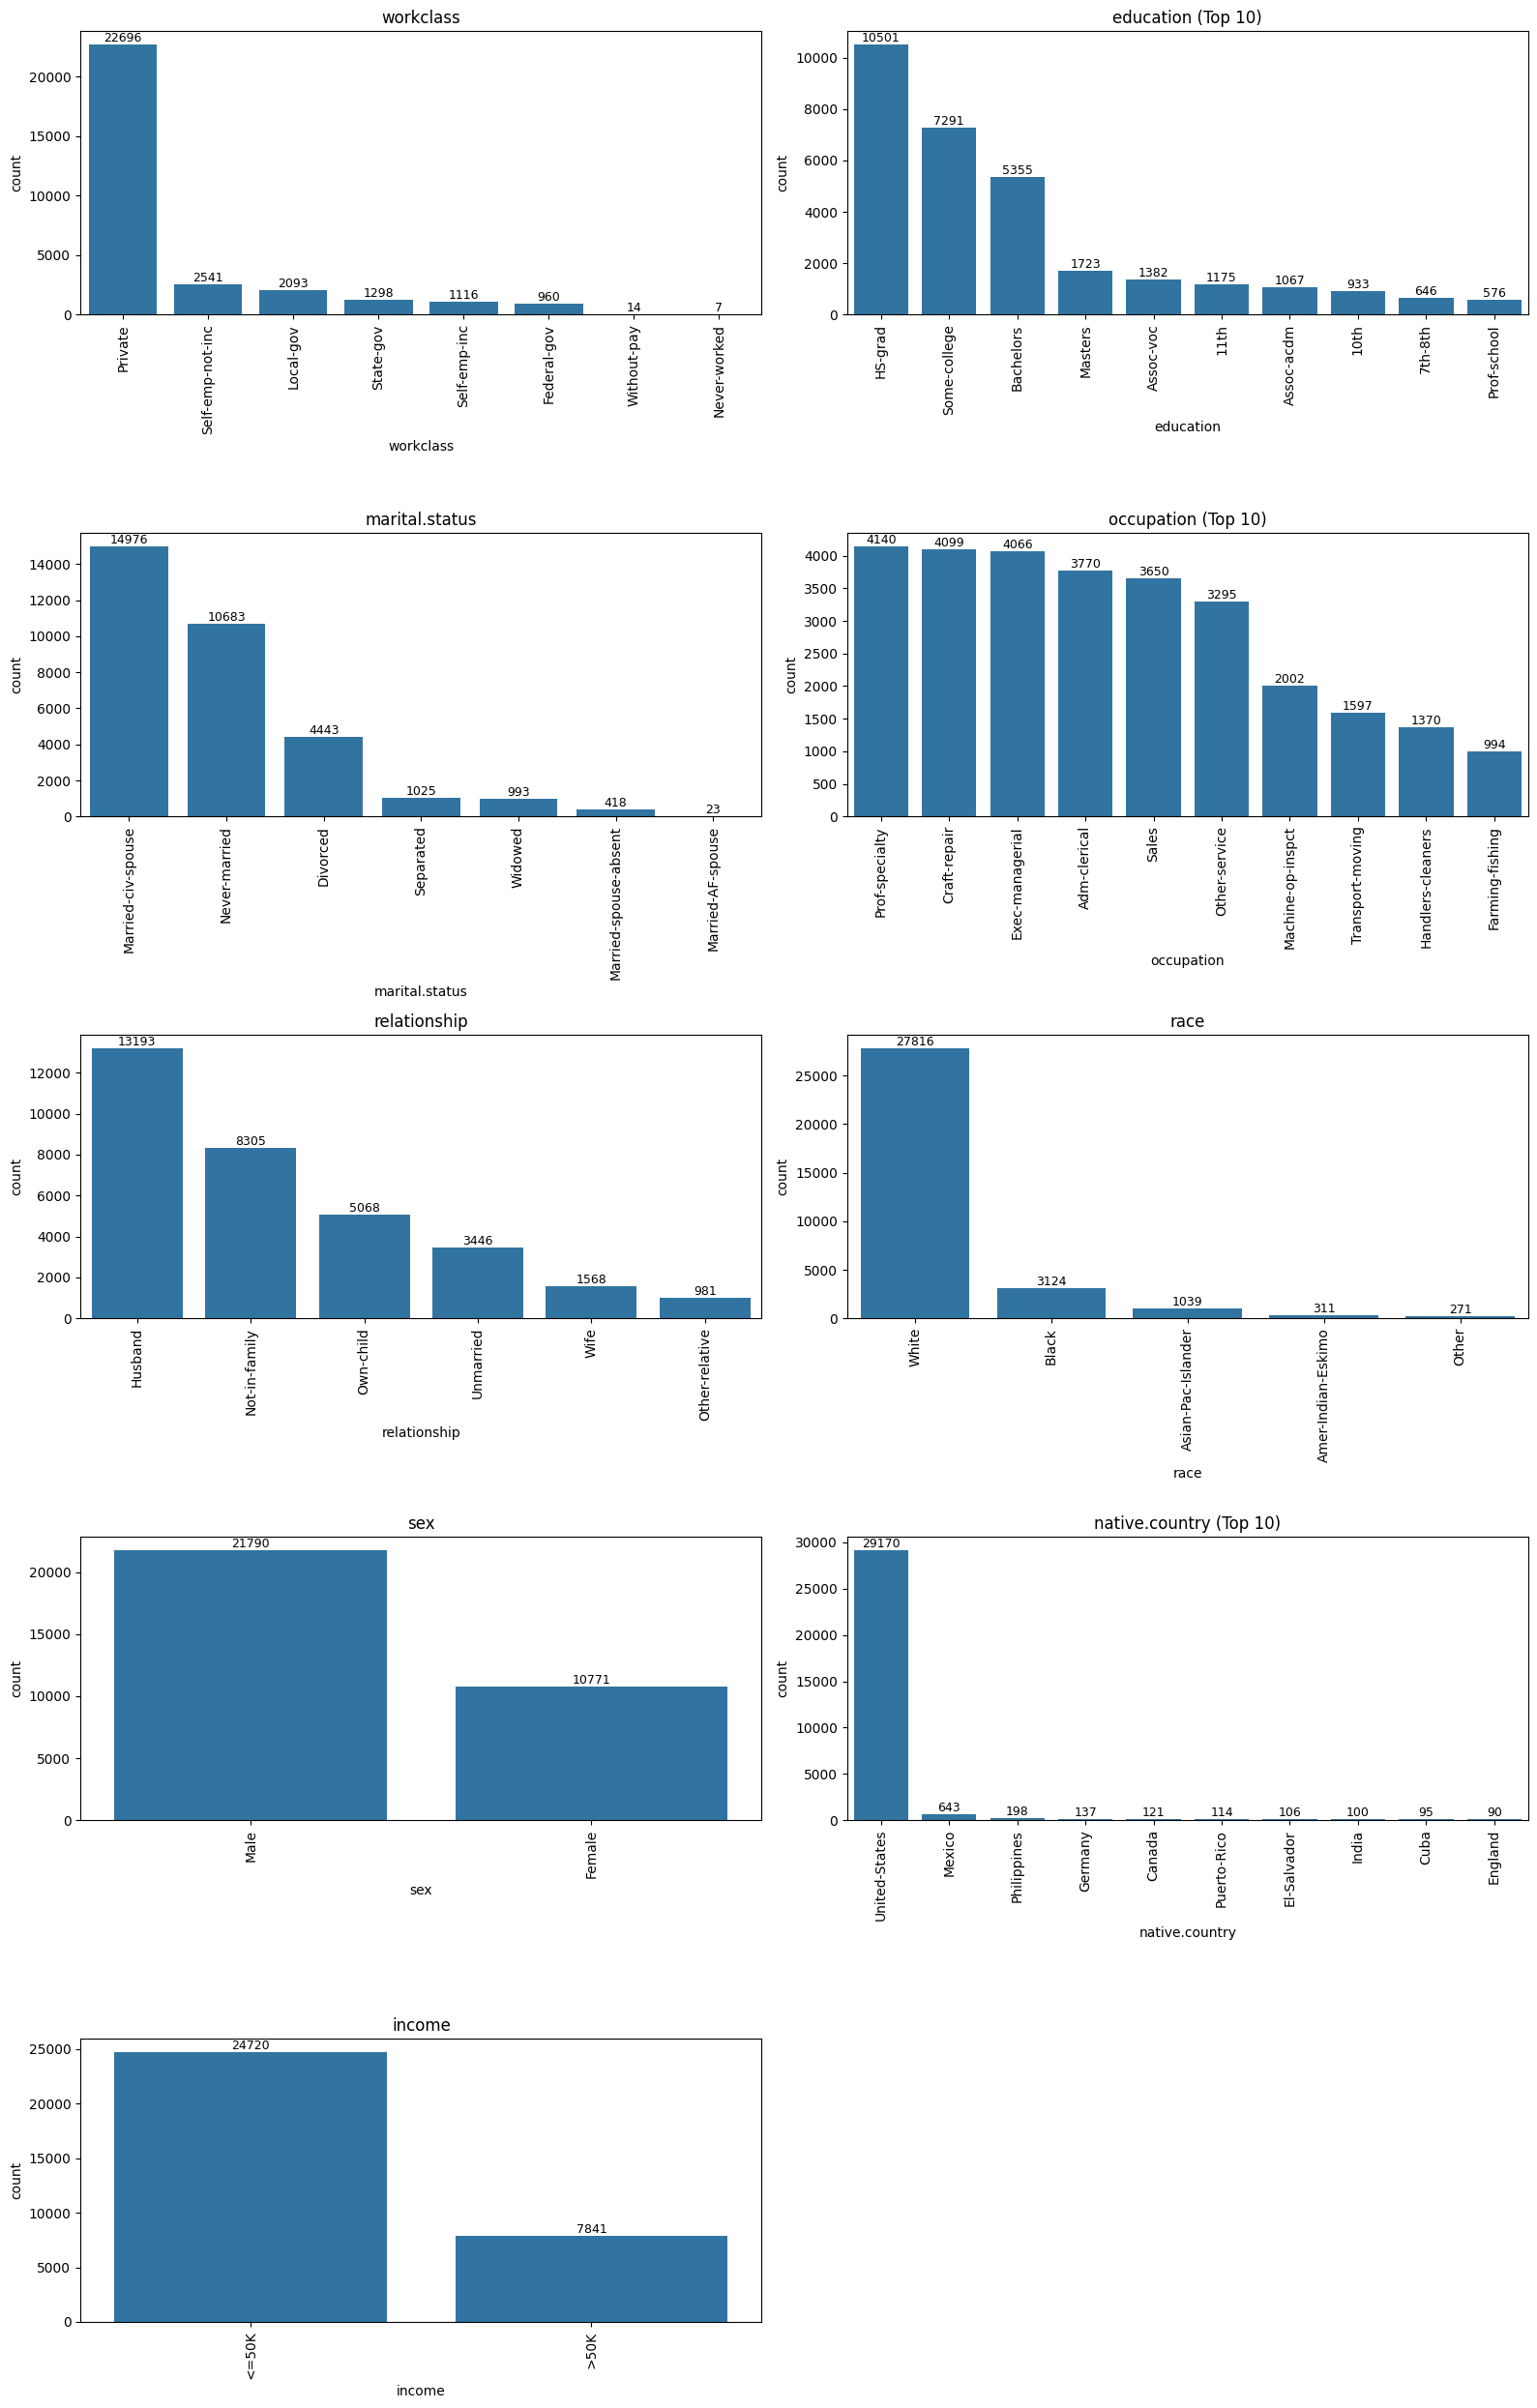

In [10]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Setup subplot grid
cols_per_row = 2
n_rows = math.ceil(len(categorical_cols) / cols_per_row)
fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    # Filter out "?" and compute value counts
    vc = df[df[col] != "?"][col].value_counts()

    # Use only top 10 if too many categories
    top_vc = vc.head(10)
    order = top_vc.index
    suffix = " (Top 10)" if len(vc) > 10 else ""

    ax = axes[i]
    
    # Plot
    sns.countplot(data=df[df[col] != "?"], x=col, order=order, ax=ax)
    ax.set_title(f"{col}{suffix}")
    ax.tick_params(axis="x", rotation=90)

    # Add labels on bars
    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center", va="bottom", fontsize=9
        )

# Remove extra axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [11]:
for col in categorical_cols:
    vc = df[df[col] != "?"][col].value_counts()
    top_ratio = (vc.iloc[0] / df.shape[0]) * 100

    if top_ratio <= 40:
        balance = "Balanced"
    elif top_ratio <= 70:
        balance = "Moderately imbalanced"
    else:
        balance = "Highly imbalanced"

    print(f"{col:<20}: {balance:<25} Top category = {vc.index[0]}, {round(top_ratio,1)}%")


workclass           : Moderately imbalanced     Top category = Private, 69.7%
education           : Balanced                  Top category = HS-grad, 32.3%
marital.status      : Moderately imbalanced     Top category = Married-civ-spouse, 46.0%
occupation          : Balanced                  Top category = Prof-specialty, 12.7%
relationship        : Moderately imbalanced     Top category = Husband, 40.5%
race                : Highly imbalanced         Top category = White, 85.4%
sex                 : Moderately imbalanced     Top category = Male, 66.9%
native.country      : Highly imbalanced         Top category = United-States, 89.6%
income              : Highly imbalanced         Top category = <=50K, 75.9%


#### 2.3.2 Data Quality
At this stage, we are examining the **quality of categorical columns** to ensure the data is suitable for analysis. Specifically, we are:

1. **Checking for missing values** – identifying placeholders (`"?"`) that indicate absent data.  
2. **Detecting inconsistencies** – looking for variations or typos in category labels (e.g., `"Male"`, `"male"`, `"M"`, `"m"`).  
3. **Identifying unexpected or abnormal values** – spotting categories that do not fit expected values.  

In [12]:
# Calculate missing values including placeholders ("?")
missing_summary = []

for col in categorical_cols:
    total = df.shape[0]
    missing_count = (df[col] == "?").sum()
    missing_pct = (missing_count / total) * 100
    missing_summary.append({
        "Column": col,
        "Missing (%)": round(missing_pct, 2)
    })

missing_df = pd.DataFrame(missing_summary)
missing_df


,Column,Missing (%)
0,workclass,5.64
1,education,0.00
2,marital.status,0.00
3,occupation,5.66
4,relationship,0.00
5,race,0.00
6,sex,0.00
7,native.country,1.79
8,income,0.00


In [13]:
# Iterate through categorical columns
for col in categorical_cols:
    print(f"Column: {col}")
    
    # Get unique values including placeholders
    unique_vals = df[df[col] != "?"][col].unique()
    
    # Count occurrences
    value_counts = df[col].value_counts(dropna=False)
    
    print(f"Unique values ({len(unique_vals)}): {unique_vals}")
    print("-"*60)

Column: workclass
Unique values (8): ['Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']
------------------------------------------------------------
Column: education
Unique values (16): ['HS-grad' 'Some-college' '7th-8th' '10th' 'Doctorate' 'Prof-school'
 'Bachelors' 'Masters' '11th' 'Assoc-acdm' 'Assoc-voc' '1st-4th' '5th-6th'
 '12th' '9th' 'Preschool']
------------------------------------------------------------
Column: marital.status
Unique values (7): ['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']
------------------------------------------------------------
Column: occupation
Unique values (14): ['Exec-managerial' 'Machine-op-inspct' 'Prof-specialty' 'Other-service'
 'Adm-clerical' 'Craft-repair' 'Transport-moving' 'Handlers-cleaners'
 'Sales' 'Farming-fishing' 'Tech-support' 'Protective-serv' 'Armed-Forces'
 'Priv-house-serv']
----------------------

**Conclusion for categorical columns**
- Most categorical columns are clean and consistent, with no major typos or inconsistent casing.   
- Some categories have very few observations (e.g., rare occupations, certain countries, low education levels) and could be grouped to reduce sparsity.  
- Several columns are highly imbalanced (e.g., `race`, `sex`, `income`), which should be considered in analysis and modeling.  
- Overall, the categorical data is usable after handling missing values and rare categories.


### 2.4 Missing Data Analysis
In this step, we summarize missing data for all columns.  
Since this dataset uses `"?"` instead of actual `NaN` values to represent missing entries,  
we count how many `"?"` values appear in each column and compute their percentage.  

This helps identify which features may require cleaning, imputation, or removal.


In [14]:
# Replace "?" with NaN for checking (but do not modify original df)
df_missing = df.replace("?", np.nan)

# Create summary table
missing_summary = pd.DataFrame({
    "Missing Count": df_missing.isna().sum(),
    "Missing Percentage (%)": (df_missing.isna().mean() * 100).round(2)
})

missing_summary


,Missing Count,Missing Percentage (%)
age,0,0.00
workclass,1836,5.64
fnlwgt,0,0.00
education,0,0.00
education.num,0,0.00
marital.status,0,0.00
occupation,1843,5.66
relationship,0,0.00
race,0,0.00
sex,0,0.00


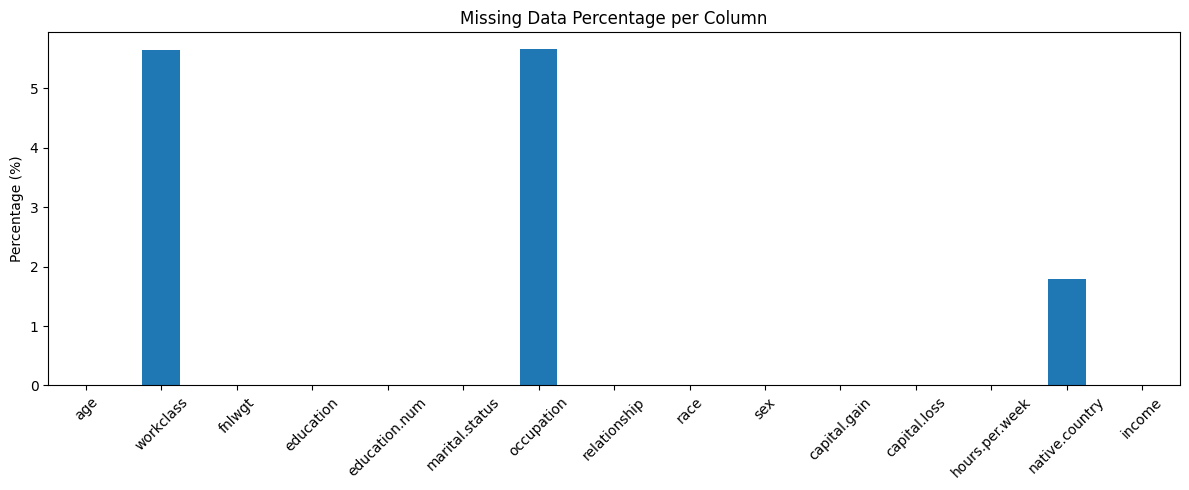

In [15]:
plt.figure(figsize=(12, 5))
missing_summary["Missing Percentage (%)"].plot(kind="bar")
plt.title("Missing Data Percentage per Column")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


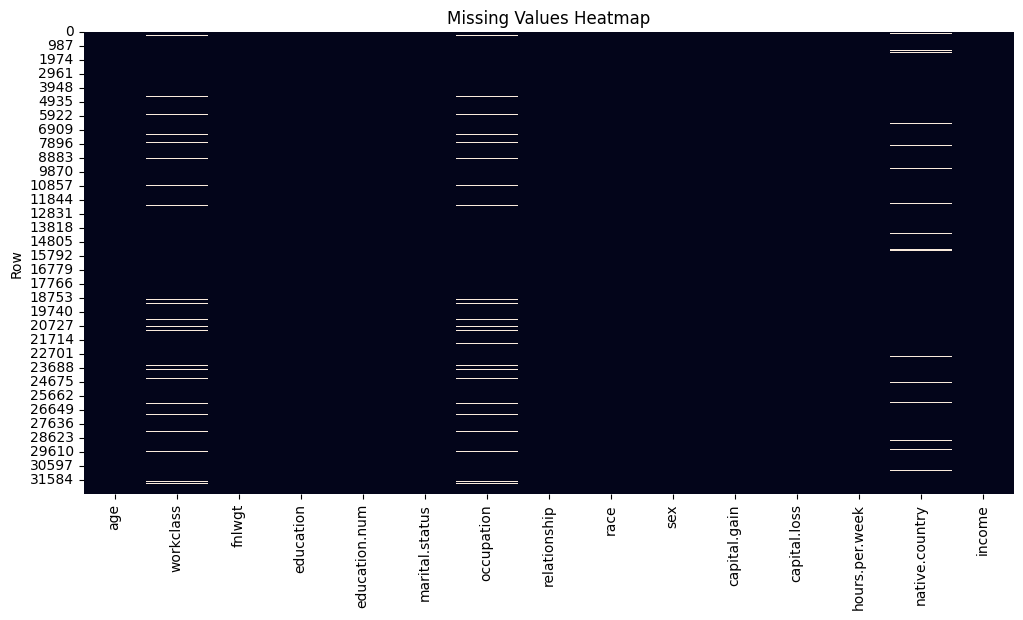

In [16]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_missing.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.ylabel("Row")
plt.show()


Based on the missing value summary and the distribution across rows:

- Only a few categorical columns contain missing values represented by `"?"`:  
  **workclass (5.64%)**, **occupation (5.66%)**, and **native.country (1.79%)**.
- Numerical columns have no missing values.
- The missing entries are **evenly distributed throughout the dataset**, from the first row to the last,  
  showing **no clustering or group-specific concentration**.

For the three columns with missing values (**workclass**, **occupation**, **native.country**), a common approach will be applied: replacing `"?"` with `"Unknown"` to preserve all rows and treat missing data as a valid category.

### 2.5 Relationships & Correlations

At this stage, we aim to explore potential relationships and patterns in the dataset.

**Preliminary Patterns:**
- For numerical variables, calculate a correlation matrix to identify strongly correlated pairs.
- Visualize correlations using a heatmap to quickly spot positive or negative relationships.
- Note any unexpected relationships between variables that could provide insights or require further investigation.

**Cross-tabulations:**
- For important categorical × categorical combinations (e.g., `marital.status` × `sex`), create frequency tables to see how categories interact.
- For numerical × categorical combinations (e.g., `hours.per.week` grouped by `income`), compute grouped summary statistics like mean, median, and standard deviation.


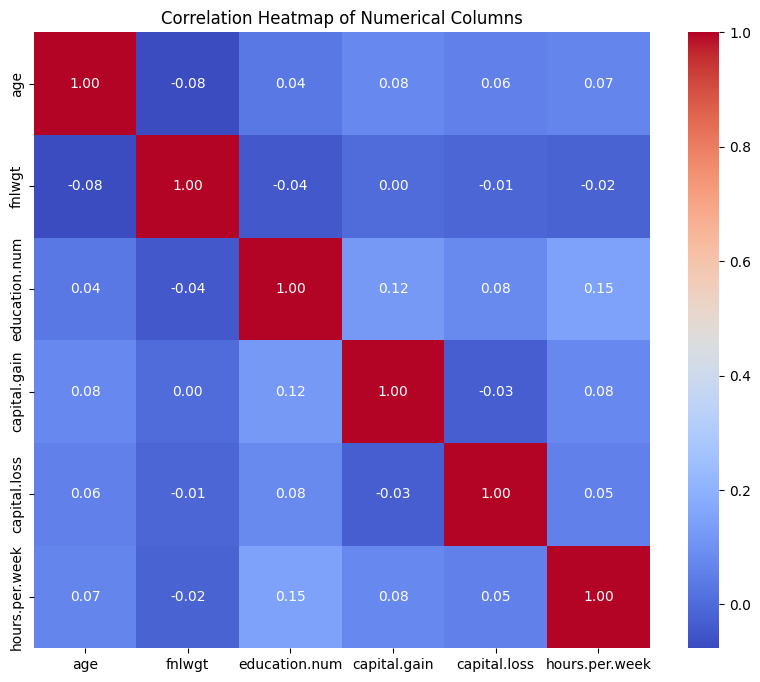

In [17]:
# Numerical correlation matrix
num_corr = df[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

In [18]:
# Categorical × Target (income)

categorical_cols = df.select_dtypes(include=['object']).columns.drop('income')  # exclude target

print("Categorical × Income Cross-tabulations:\n")

for col in categorical_cols:
    # Exclude placeholder values
    values = df[df[col] != "?"][col]
    
    # Cross-tabulation
    ctab = pd.crosstab(values, df.loc[values.index, 'income'], normalize='index') * 100
    ctab = ctab.round(2)
    ctab = ctab.astype(str) + "%"

    print(f"Column: {col}")
    display(ctab)
    print("-"*60)

Categorical × Income Cross-tabulations:

Column: workclass


income,<=50K,>50K
workclass,,
Federal-gov,61.35%,38.65%
Local-gov,70.52%,29.48%
Never-worked,100.0%,0.0%
Private,78.13%,21.87%
Self-emp-inc,44.27%,55.73%
Self-emp-not-inc,71.51%,28.49%
State-gov,72.8%,27.2%
Without-pay,100.0%,0.0%


------------------------------------------------------------
Column: education


income,<=50K,>50K
education,,
10th,93.35%,6.65%
11th,94.89%,5.11%
12th,92.38%,7.62%
1st-4th,96.43%,3.57%
5th-6th,95.2%,4.8%
7th-8th,93.81%,6.19%
9th,94.75%,5.25%
Assoc-acdm,75.16%,24.84%
Assoc-voc,73.88%,26.12%


------------------------------------------------------------
Column: marital.status


...

------------------------------------------------------------
Column: sex


income,<=50K,>50K
sex,,
Female,89.05%,10.95%
Male,69.43%,30.57%


------------------------------------------------------------
Column: native.country


income,<=50K,>50K
native.country,,
Cambodia,63.16%,36.84%
Canada,67.77%,32.23%
China,73.33%,26.67%
Columbia,96.61%,3.39%
Cuba,73.68%,26.32%
Dominican-Republic,97.14%,2.86%
Ecuador,85.71%,14.29%
El-Salvador,91.51%,8.49%
England,66.67%,33.33%


------------------------------------------------------------


### 2.6 Initial Observations & Insights

**Summary:**
- The dataset contains 15 features plus the target variable `income`, a mix of numerical and categorical types.
- High-potential features include: `age`, `education`, `marital.status`, `hours.per.week`, `sex`, and `native.country`.
- Numerical variables show very weak correlations (mostly between -0.1 and 0.1), indicating low multicollinearity.
- Categorical variables are often imbalanced, e.g., `sex`, `race`, and `native.country`.
- Outliers exist in `age`, `fnlwgt`and `hours.per.week`, but most are plausible and should be retained.

**Data Quality Issues:**
- Missing values are present in `workclass` (5.6%), `occupation` (5.7%), and `native.country` (1.8%), represented by `?`.
- High-cardinality categorical features such as `native.country` may need grouping.
- Placeholders (`?`) and rare categories need to be handled prior to modeling.

**The Recommendations For Preprocessing Steps:**
- Convert categorical columns to `category` type for efficiency.
- Replace `?` with `'Unknown'` in categorical columns.
- Drop or treat low-variance numeric columns (`capital.gain`, `capital.loss`) as optional.
- Normalize numerical variables if using magnitude-sensitive models.
- Group rare categories in high-cardinality categorical features.

**Interesting Patterns:**
- Income differences are notable across `education`, `marital.status`, `hours.per.week`, and `sex`.
- No strong linear correlations among numerical features; most predictive power comes from categorical interactions.

**Red Flags:**
- Data is from 1994 and may not reflect current socioeconomic conditions.
- Gender imbalance and other categorical imbalances may bias models.
- Small amount of missing data may introduce minor noise if not handled.
- The `fnlwgt` column may not be useful for modeling.
